## analysing the changes in tropical rain belts post net zero using ACCESS net zero runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [23]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [24]:
def plot_background(ax, draw_labels=False, set_locator=False, xloc=[], yloc=[]):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    if set_locator:
        gl.xlocator = mticker.FixedLocator(xloc)
        gl.ylocator = mticker.FixedLocator(yloc)
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', set_locator=False, xloc=[], yloc=[],
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj}, sharex=True, sharey=True)
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax, draw_labels, set_locator, xloc, yloc)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[130, 0], width=150, height=20,
                                                        facecolor='none', edgecolor='k',
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[130, -20], width=90, height=20,
                                                        facecolor='none', edgecolor='k',
                                                        transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[100, -20], width=200, height=40,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', set_locator=False, xloc=[], yloc=[],
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    plot_background(ax, draw_labels, set_locator, xloc, yloc)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        ax.quiver(x[::3, ::3], y[::3, ::3], u_wnd.to_numpy()[::3, ::3], v_wnd.to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
        ax.pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[100, -20], width=200, height=40,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

### import data

In [9]:
from dask.diagnostics import ProgressBar

In [10]:
with ProgressBar():
    pr_trans_orig = (xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_pr_original.nc').pr*86400*30).load()
pr_trans = funcs.calc_anom(pr_trans_orig, pr_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

[########################################] | 100% Completed | 37.08 s


In [11]:
pr_pic_orig = (xr.open_mfdataset('/g/data/if69/as8561/data/piControl_data/pr_pic.nc').sel(model = 'ACCESS-ESM1-5').pr*86400*30).load()

In [12]:
with ProgressBar():
    pr_stable_orig = (xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_pr.nc').pr*86400*30).load()
pr_stable = funcs.calc_anom(pr_stable_orig, pr_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

[########################################] | 100% Completed | 27.48 ss


In [13]:
with ProgressBar():
    ts_trans_orig = (xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_ts_original.nc').ts).load()
ts_trans = funcs.calc_anom(ts_trans_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

[########################################] | 100% Completed | 15.02 s


In [14]:
ts_pic_orig = (xr.open_mfdataset('/g/data/if69/as8561/data/piControl_data/ts_pic.nc').sel(model = 'ACCESS-ESM1-5').ts).load()

In [15]:
with ProgressBar():
    ts_stable_orig = (xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_ts.nc').ts).load()
ts_stable = funcs.calc_anom(ts_stable_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

[########################################] | 100% Completed | 3.66 ss


In [16]:
weights_model = np.cos(np.deg2rad(pr_trans.lat))

In [17]:
plot_list = [
    (pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2040', '2060')).mean(('model', 'time')),
    (pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [18]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [19]:
contour_data = [
    (pr_pic_orig).sel(lat = slice(-40, 40)).mean('time').compute(),
    (pr_pic_orig).sel(lat = slice(-40, 40)).mean('time').compute(),
    (pr_pic_orig).sel(lat = slice(-40, 40)).mean('time').compute(),
]

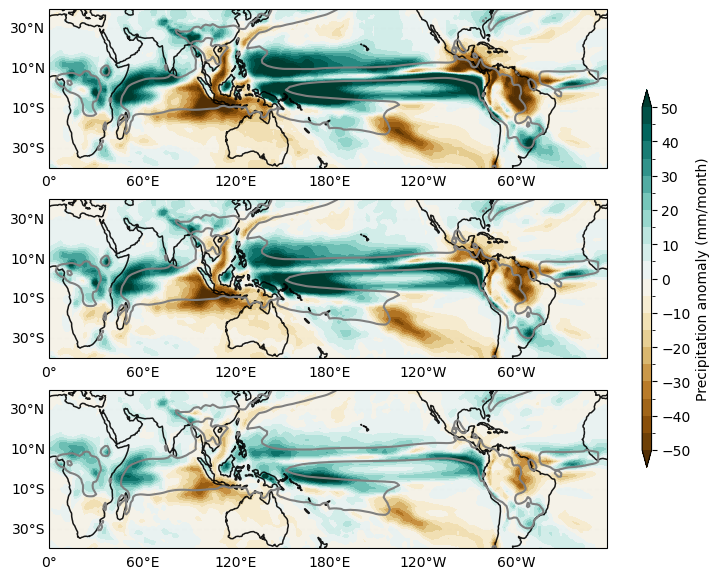

In [49]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap='BrBG', levels = np.linspace(-50, 50, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=contour_data, contour_levels=[150], contour_colors='tab:gray',
            set_locator=True, yloc=[-30, -10, 10, 30], xloc=[-120, -60, 0, 60, 120, 180],
            nrows=3, ncols=1, figsize=(9,7), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180),
            cbar_kwargs=dict(orientation='vertical', label='Precipitation anomaly (mm/month)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)

In [40]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [41]:
stable_plot_list = [
    additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2060').sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2045').sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


In [42]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

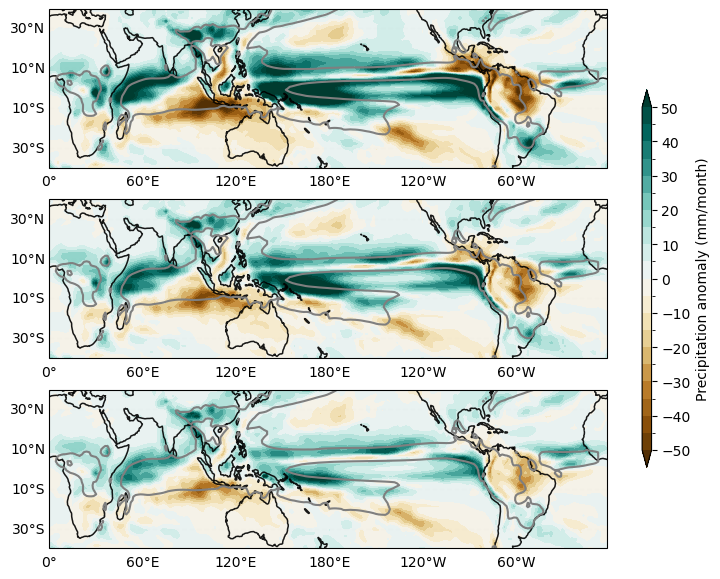

In [50]:
plot_maps(xx, yy, stable_plot_list, ['']*3, ['']*3, cmap='BrBG', levels = np.linspace(-50, 50, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=contour_data, contour_levels=[150], contour_colors='tab:gray', 
            set_locator=True, yloc=[-30, -10, 10, 30], xloc=[-120, -60, 0, 60, 120, 180],
            nrows=3, ncols=1, figsize=(9,7), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Precipitation anomaly (mm/month)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)

In [44]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [45]:
pval_list = [
    funcs.mannwhitneyu3d((pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2045', '2075')).mean(('time')), additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2060').sel(time = slice('2060', '3060'))), dim='model'),
    funcs.mannwhitneyu3d((pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2030', '2060')).mean(('time')), additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2045').sel(time = slice('2045', '3045'))), dim='model'),
    funcs.mannwhitneyu3d((pr_trans).sel(lat = slice(-40, 40)).sel(time = slice('2015', '2045')).mean(('time')), additional_sampling_stabilisation((pr_stable).sel(lat = slice(-40, 40)).sel(model = 'B2030').sel(time = slice('2030', '3030'))), dim='model'),
]

Done
Done
Done


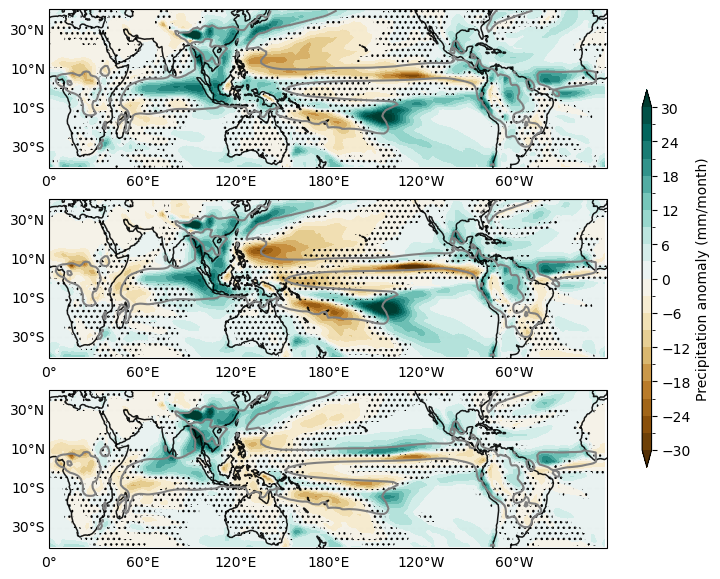

In [51]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap='BrBG', levels = np.linspace(-30, 30, 21), pval = pval_list, draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=True, contour_data=contour_data, contour_levels=[150], contour_colors='tab:gray', 
            set_locator=True, yloc=[-30, -10, 10, 30], xloc=[-120, -60, 0, 60, 120, 180],
            nrows=3, ncols=1, figsize=(9,7), land_mask_list = [], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='Precipitation anomaly (mm/month)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)

In [35]:
def find_itcz_spcz_position_model_spread(pr_da, type='trans'):
    if type == 'trans':
        input_da = pr_da
    elif type == 'stable':
        input_da = pr_da
    itcz_box = input_da.sel(lat = slice(0,20), lon = slice(130, -80+360))
    spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -140+360))
    # itcz_box = input_da.sel(lat = slice(0,20))
    # spcz_box = input_da.sel(lat = slice(-20,0))
    # spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -80+360))
    # maximum of the zonally averaged precipitation in each hemisphere
    itcz_loc = itcz_box.lat.where(itcz_box >= itcz_box.mean('lon').max('lat')).mean(('lat', 'lon'))
    spcz_loc = spcz_box.lat.where(spcz_box >= spcz_box.mean('lon').max('lat')).mean(('lat', 'lon'))
    net_loc = np.abs(itcz_loc) + np.abs(spcz_loc)
    return itcz_loc, spcz_loc, net_loc
    # return itcz_loc[~np.isnan(itcz_loc)], spcz_loc[~np.isnan(spcz_loc)]

In [36]:
itcz_loc_pi, spcz_loc_pi, net_loc_pi = find_itcz_spcz_position_model_spread(pr_pic_orig)
itcz_loc_trans, spcz_loc_trans, net_loc_trans = find_itcz_spcz_position_model_spread(pr_trans_orig)

In [37]:
itcz_loc_stable, spcz_loc_stable, net_loc_stable = find_itcz_spcz_position_model_spread(pr_stable_orig, type='stable')

In [38]:
# import seaborn as sns

Text(0, 0.5, 'Latitude of ITCZ ($^{o}$N)')

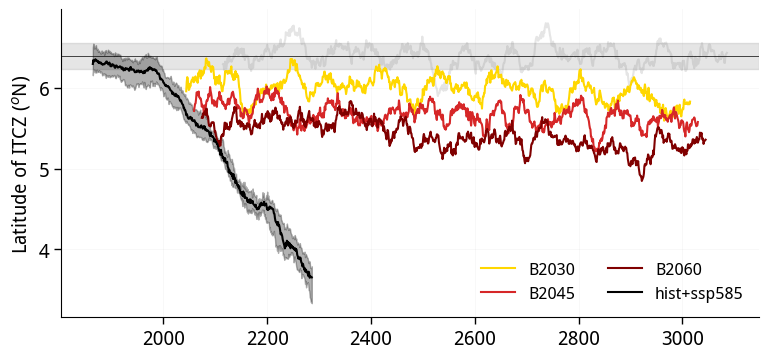

In [39]:
plt.figure(figsize=(9,4))

xdata = itcz_loc_pi.rolling(time = 30, center=True).mean('time').time.dt.year + 2000
plt.plot(xdata, itcz_loc_pi.rolling(time = 30, center=True).mean('time'), color='tab:gray', alpha=0.2)
plt.axhspan(itcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.1, 'time'), itcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(itcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(itcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(itcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(itcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(itcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, itcz_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_itcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), conc_itcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=2)
plot_decorator()
plt.ylabel('Latitude of ITCZ ($^{o}$N)')
# plt.xlabel('Year')


Text(0, 0.5, 'Latitude of SPCZ ($^{o}$S)')

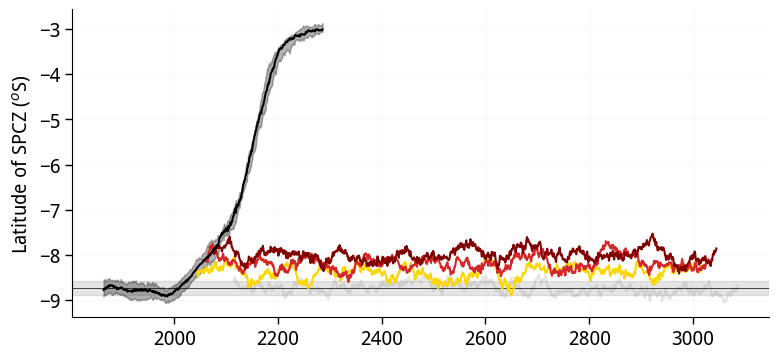

In [40]:
plt.figure(figsize=(9,4))

xdata = spcz_loc_pi.rolling(time = 30, center=True).mean('time').time.dt.year + 2000
plt.plot(xdata, spcz_loc_pi.rolling(time = 30, center=True).mean('time'), color='tab:gray', alpha=0.2)
plt.axhspan(spcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.1, 'time'), spcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(spcz_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(spcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(spcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(spcz_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(spcz_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, spcz_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_spcz_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), conc_spcz_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
# plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=5, bbox_to_anchor=(1.1, 1.05))
plot_decorator()
plt.ylabel('Latitude of SPCZ ($^{o}$S)')
# plt.xlabel('Year')


Text(0, 0.5, 'Location of convergence zones \nrelative to equator ($^{o}$)')

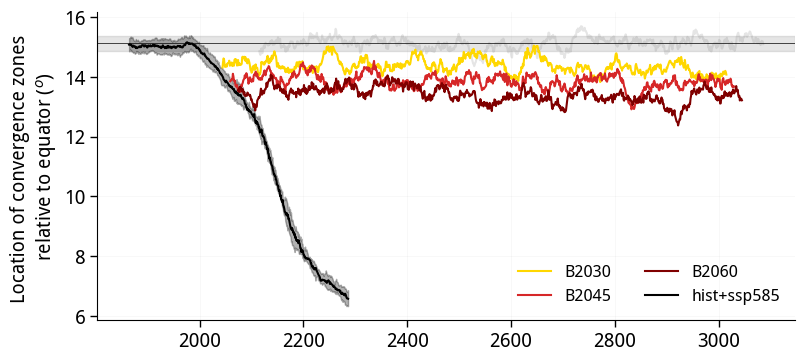

In [41]:
plt.figure(figsize=(9,4))

xdata = net_loc_pi.rolling(time = 30, center=True).mean('time').time.dt.year + 2000
plt.plot(xdata, net_loc_pi.rolling(time = 30, center=True).mean('time'), color='tab:gray', alpha=0.2)
plt.axhspan(net_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.1, 'time'), net_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(net_loc_pi.rolling(time = 30, center=True).mean('time').quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(net_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(net_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(net_loc_stable.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model = 'B2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(net_loc_stable.rolling(time = 30, center=True).mean('time').sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

plt.plot(net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585')
# plt.plot(net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='k', alpha=0.3)

# plt.plot(conc_net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), color='tab:blue', lw=1.5, label='hist+ssp585', alpha=0.3)
# plt.plot(net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, net_loc_trans.rolling(time = 30, center=True).mean('time').sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(conc_net_loc_trans.rolling(time = 30, center=True).mean('time').time.dt.year, conc_net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.1, 'model'), conc_net_loc_trans.rolling(time = 30, center=True).mean('time').quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

# sns.despine(trim=True)
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=2)
plot_decorator()
plt.ylabel('Location of convergence zones \nrelative to equator ($^{o}$)')
# plt.xlabel('Year')


###  analysing changes in SST threshold for convection and convective area in deep tropics

In [42]:
os.environ['PROJ_LIB'] = '/g/data/xp65/public/apps/med_conda/envs/analysis3-24.04/share/proj'

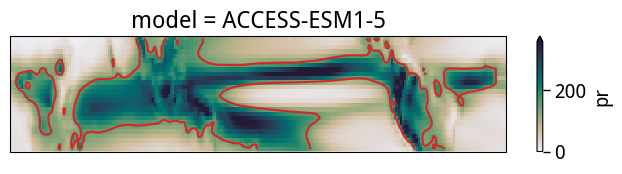

In [53]:
plt.figure(figsize=(8,1.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
pr_pic_orig.sel(lat = slice(-20, 20)).mean('time').plot(vmin=0, vmax=360, cmap=cmocean.cm.rain, transform=ccrs.PlateCarree())#, cbar_kwargs = dict(orientation='horizontal', shrink=0.8, aspect=40))
pr_pic_orig.sel(lat = slice(-20, 20)).mean('time').plot.contour(levels=[150], colors='tab:red', transform=ccrs.PlateCarree())#, cbar_kwargs = dict(orientation='horizontal', shrink=0.8, aspect=40))
# (ts_pic_orig - 273).sel(lat = slice(-20, 20)).isel(time = slice(0, 100)).mean('time').plot(cmap='Spectral_r', vmin=20, center=26.5, transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40))
# (ts_thresh_pic - 273).isel(time = slice(0, 100)).mean('time').plot.contourf(cmap='Spectral_r', levels=21, transform=ccrs.PlateCarree())
# plot_background(ax, draw_labels=True)
# ax.coastlines()

In [54]:
ts_thresh_pic = ts_pic_orig.sel(lat = slice(-20, 20)).where(pr_pic_orig.sel(lat = slice(-20, 20)) >= 150)
ts_thresh_pic

<xarray.DataArray 'ts' (time: 2001, lat: 26, lon: 240)> Size: 50MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
  * lat      (lat) float64 208B -18.75 -17.25 -15.75 ... 15.75 17.25 18.75
  * time     (time) object 16kB 0100-12-31 00:00:00 ... 2100-12-31 00:00:00
    model    <U16 64B 'ACCESS-ESM1-5'
Attributes:
    standard_name:  surface_temperature
    long_name:      Surface Temperature
    units:          K
    comment:        GT+273.16, CMIP_table_comment: Temperature of the lower b...
    original_name:  GT
    history:        degctok 2019-05-09T01:22:42Z altered by CMOR: Reordered d...
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

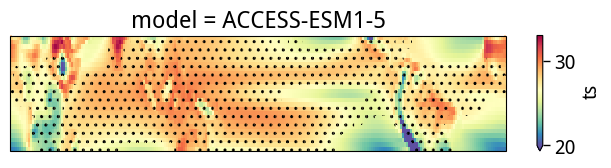

In [55]:
plt.figure(figsize=(8,1.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
(ts_pic_orig - 273).sel(lat = slice(-20, 20)).mean('time').plot(cmap='Spectral_r', vmin=20, center=26.5, transform=ccrs.PlateCarree())
# (ts_thresh_pic - 273).isel(time = slice(0, 100)).mean('time').plot.contourf(cmap='Spectral_r', levels=21, transform=ccrs.PlateCarree())
xx, yy = np.meshgrid(ts_thresh_pic.lon, ts_thresh_pic.lat)
zz = xr.where(ts_pic_orig == ts_thresh_pic, 1, 0)
zzz = np.ma.masked_equal(zz.mean('time'), 0)
ax.pcolor(xx, yy, zzz, alpha=0., hatch='..', transform=ccrs.PlateCarree())
# plot_background(ax, draw_labels=True)

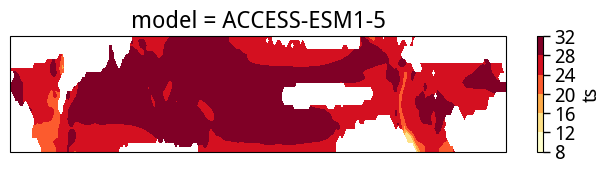

In [56]:
plt.figure(figsize=(8,1.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_aspect('auto')
# (ts_pic_orig - 273).sel(lat = slice(-20, 20)).isel(time = slice(0, 100)).mean('time').plot(cmap='RdBu_r', vmin=20, center=26.5, transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40))
(ts_pic_orig - 273).where(ts_pic_orig == ts_thresh_pic).mean('time').plot.contourf(cmap='YlOrRd', transform=ccrs.PlateCarree())
# plot_background(ax, draw_labels=True)

In [65]:
ts_thresh_pic = ts_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150).min(('lat')).rolling(time = 30, center=True).mean('time')
convective_area_pic = (pr_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).isel(time = slice(0, 1000)).rolling(time = 30, center=True).mean('time')
# non_convective_area_pic = (pr_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_pic_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) < 30, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).isel(time = slice(0, 1000)).rolling(time = 11, center=True).mean('time')

ts_thresh_pic_wp = (ts_thresh_pic - 273).isel(time = slice(0, 1000)).sel(lon = slice(140, 170)).mean(('lon'))
ts_thresh_pic_ep = (ts_thresh_pic - 273).isel(time = slice(0, 1000)).sel(lon = slice(190, 270)).mean(('lon'))

In [58]:
ts_trans_orig = ts_trans_orig.sortby('model')
pr_trans_orig = pr_trans_orig.sortby('model')
ts_trans_orig['model'] = pr_trans_orig['model']

In [59]:
ts_stable_orig = ts_stable_orig.sortby('model')
pr_stable_orig = pr_stable_orig.sortby('model')
ts_stable_orig['model'] = pr_stable_orig['model']
ts_stable_orig['time'] = pr_stable_orig['time']

In [60]:
ts_thresh_trans = ts_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150).min(('lat')).sel(time = slice('1850', '2100')).rolling(time = 30, center=True).mean('time')
convective_area_trans = (pr_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).sel(time = slice('1850', '2100')).rolling(time = 30, center=True).mean('time')
# non_convective_area_trans = (pr_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_trans_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) < 30, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).sel(time = slice('1850', '2100')).rolling(time = 11, center=True).mean('time')

ts_thresh_trans_wp = (ts_thresh_trans - 273).sel(lon = slice(140, 170)).mean(('lon'))
ts_thresh_trans_ep = (ts_thresh_trans - 273).sel(lon = slice(190, 270)).mean(('lon'))


In [61]:
ts_thresh_stable = ts_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150).min(('lat')).rolling(time = 30, center=True).mean('time')
convective_area_stable = (pr_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) >= 150, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).rolling(time = 30, center=True).mean('time').isel(time = slice(35, -35))
# non_convective_area_stable = (pr_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)).where(pr_stable_orig.sel(lat = slice(-20, 20), lon = slice(100, 300)) < 30, drop=True).count(('lat', 'lon'))*(1e4 * 1.5)).rolling(time = 11, center=True).mean('time').isel(time = slice(35, -35))


ts_thresh_stable_wp = (ts_thresh_stable - 273).sel(lon = slice(140, 170)).mean(('lon'))
ts_thresh_stable_ep = (ts_thresh_stable - 273).sel(lon = slice(190, 270)).mean(('lon'))


Text(0, 0.5, 'Threshold for convection (degC)')

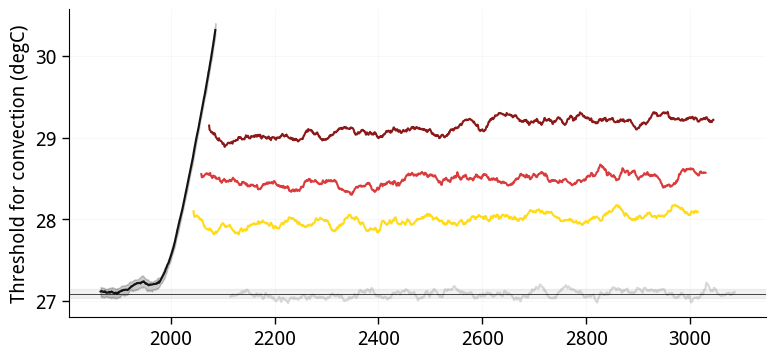

In [66]:
plt.figure(figsize=(9, 4))
xdata = ts_thresh_pic_ep.time.dt.year + 2000
plt.plot(xdata, ts_thresh_pic_ep, color='tab:gray', alpha=0.3)
plt.axhspan(ts_thresh_pic_ep.quantile(0.1, 'time'), ts_thresh_pic_ep.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
plt.axhline(ts_thresh_pic_ep.quantile(0.5, 'time'), color='k', lw=0.5)


xdata = ts_thresh_trans_ep.time.dt.year
plt.plot(xdata, ts_thresh_trans_ep.quantile(0.5, 'model'), color='k', alpha=0.9)
plt.fill_between(xdata, ts_thresh_trans_ep.quantile(0.1, 'model'), ts_thresh_trans_ep.quantile(0.9, 'model'), color='k', alpha=0.2)

xdata = ts_thresh_stable_ep.time.dt.year
plt.plot(xdata, ts_thresh_stable_ep.sel(model = 'B2060'), color='maroon', alpha=0.9)

plt.plot(xdata, ts_thresh_stable_ep.sel(model = 'B2045'), color='tab:red', alpha=0.9)

plt.plot(xdata, ts_thresh_stable_ep.sel(model = 'B2030'), color='gold', alpha=0.9)
plot_decorator()
plt.ylabel('Threshold for convection (degC)')
## this is the SST threhold for convection i.e. the minimum SST at which deep convection is triggered in the East Pacific cold tongue region and the threhold is increasing even after net zero indicative persistent shift in the temperature patterns

In [67]:
def fix_da(da):
    da_detrend = funcs.detrend_rolling_window(da, window_size=50)
    return da.where(da_detrend < 7*da_detrend.std('time'))

Text(0, 0.5, 'Convective area (km$^{2}$)')

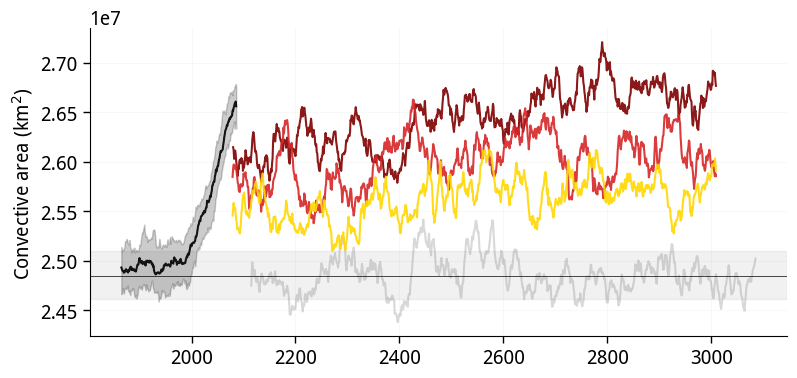

In [68]:

plt.figure(figsize=(9, 4))
xdata = convective_area_pic.time.dt.year + 2000
plt.plot(xdata, convective_area_pic, color='tab:gray', alpha=0.3)
plt.axhspan(fix_da(convective_area_pic).quantile(0.1, 'time'), convective_area_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
plt.axhline(fix_da(convective_area_pic).quantile(0.5, 'time'), color='k', lw=0.5)


xdata = convective_area_trans.time.dt.year
plt.plot(xdata, convective_area_trans.quantile(0.5, 'model'), color='k', alpha=0.9)
plt.fill_between(xdata, convective_area_trans.quantile(0.1, 'model'), convective_area_trans.quantile(0.9, 'model'), color='k', alpha=0.2)

xdata = (convective_area_stable.isel(time = slice(15, -15))).time.dt.year
plt.plot(xdata, fix_da(convective_area_stable).isel(time = slice(15, -15)).sel(model = 'B2060'), color='maroon', alpha=0.9)

plt.plot(xdata, fix_da(convective_area_stable).isel(time = slice(15, -15)).sel(model = 'B2045'), color='tab:red', alpha=0.9)

plt.plot(xdata, fix_da(convective_area_stable).isel(time = slice(15, -15)).sel(model = 'B2030'), color='gold', alpha=0.9)
plot_decorator()
plt.ylabel(r'Convective area (km$^{2}$)')
## convective area changes in the deep tropics (-5 to 5) in the Pacific sector

In [364]:
# plt.figure(figsize=(9, 4))
# xdata = non_convective_area_pic.time.dt.year + 2000
# plt.plot(xdata, non_convective_area_pic, color='tab:gray', alpha=0.3)
# plt.axhspan(fix_da(non_convective_area_pic).quantile(0.1, 'time'), non_convective_area_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
# plt.axhline(fix_da(non_convective_area_pic).quantile(0.5, 'time'), color='k', lw=0.5)


# xdata = non_convective_area_trans.time.dt.year
# plt.plot(xdata, non_convective_area_trans.quantile(0.9, 'model'), color='k', alpha=0.9)
# # plt.fill_between(xdata, non_convective_area_trans.quantile(0.1, 'model'), non_convective_area_trans.quantile(0.9, 'model'), color='k', alpha=0.2)

# xdata = non_convective_area_stable.time.dt.year
# plt.plot(xdata, fix_da(non_convective_area_stable).sel(model = 'B2060'), color='maroon', alpha=0.9)

# plt.plot(xdata, fix_da(non_convective_area_stable).sel(model = 'B2045'), color='tab:red', alpha=0.9)

# plt.plot(xdata, fix_da(non_convective_area_stable).sel(model = 'B2030'), color='gold', alpha=0.9)
# plot_decorator()
# plt.ylabel(r'Non convective area (km$^{2}$)')
# ## non_convective area changes in the deep tropics (-5 to 5) in the Pacific sector